<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Deep Learning and Reinforcement Learning**

## Module 1 - Introduction to Neural Networks
### Jaringan Saraf Tiruan dengan SKlearn

Estimasi waktu yang dibutuhkan: **30** menit

Dalam lab ini, kita akan mengimplementasikan jaringan saraf tiruan (Neural Networks) untuk tugas dunia nyata, yaitu **pengenalan digit tangan**, menggunakan pengklasifikasi **Multi-layer Perceptron (MLP)** dari pustaka scikit-learn.


## Daftar Isi

<ol>
    <li><a href="#Objectives">Tujuan Pembelajaran</a></li>
    <li>
        <a href="#Setup">Persiapan (Setup)</a>
        <ol>
            <li><a href="#Installing-Required-Libraries">Menginstal Pustaka yang Diperlukan</a></li>
            <li><a href="#Importing-Required-Libraries">Mengimpor Pustaka yang Diperlukan</a></li>
        </ol>       
    </li>
    <li><a href="#Background">Latar Belakang</a></li>
    <li><a href="#Example: Digit Recognition with Multi-layer Perceptron">Contoh: Pengenalan Digit dengan Multi-layer Perceptron</a></li>
</ol>


## Tujuan Pembelajaran

Setelah menyelesaikan lab ini, Anda akan mampu:

*   Menerapkan model MLP untuk tugas klasifikasi.
*   Menggunakan `RandomizedSearchCV` untuk mencari set parameter model yang optimal secara efisien.


## Persiapan (Setup)


Untuk lab ini, kita akan menggunakan beberapa pustaka berikut:

*   [`numpy`](https://numpy.org/) untuk operasi matematika dan manipulasi array.
*   [`Pillow`](https://pillow.readthedocs.io/en/stable/) untuk fungsi pemrosesan gambar.
*   [`OpenCV`](https://docs.opencv.org/4.x/index.html) untuk fungsi pemrosesan gambar tingkat lanjut.
*   [`tensorflow`](https://www.tensorflow.org/) untuk fungsi terkait machine learning dan jaringan saraf.
*   [`matplotlib`](https://matplotlib.org/) untuk visualisasi data dan plot.
*   [`scikit-learn`](https://scikit-learn.org/) untuk algoritma machine learning (MLP dan tuning parameter).


### Menginstal Pustaka yang Diperlukan

Pustaka-pustaka berikut sudah terinstal di lingkungan Skills Network Labs. Namun, jika Anda menjalankan notebook ini di lingkungan Jupyter lain (seperti Watson Studio atau Anaconda), Anda perlu menginstal pustaka ini dengan menghapus tanda `#` sebelum `!pip` pada sel kode di bawah ini.


In [2]:
# Semua pustaka yang diperlukan tercantum di bawah ini.
# !pip install numpy==1.22.3 matplotlib==3.5.1 tensorflow==2.9.0 opencv-python==4.5.5.62 pandas scikit-learn

# JANGAN LUPA RESTART KERNEL SETELAH INSTALASI

### Mengimpor Pustaka yang Diperlukan

Kita disarankan untuk mengimpor semua pustaka di satu tempat (di sini):


In [3]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

## Latar Belakang

Pustaka **scikit-learn** sangat populer karena menyediakan alat yang tangguh dan efisien untuk Machine Learning, seperti regresi, klasifikasi, dan pengelompokan (clustering). Pustaka ini juga memiliki antarmuka untuk bekerja dengan jaringan saraf tiruan melalui kelas **Multi-layer Perceptron (MLP)**.

**Multilayer Perceptron (MLP)** adalah kelas jaringan saraf tiruan *feedforward* yang terhubung sepenuhnya (*fully connected*). MLP terdiri dari setidaknya tiga lapisan node:
1. **Input Layer** (Lapisan Masukan)
2. **Hidden Layer** (Lapisan Tersembunyi)
3. **Output Layer** (Lapisan Keluaran)

Kecuali lapisan masukan, setiap lapisan mengandung node (neuron) yang menggunakan fungsi aktivasi non-linear (seperti **ReLU**) untuk mempelajari fitur yang kompleks dan abstrak dari data masukan.

Kelas `MLPClassifier` menggunakan teknik pembelajaran terawasi (*supervised learning*) yang disebut **backpropagation** untuk proses pelatihan. Banyaknya lapisan dan aktivasi non-linear membedakan model MLP dari model linear biasa, sehingga MLP mampu membedakan data yang tidak dapat dipisahkan secara linear.

Penting untuk dicatat bahwa MLP sering disebut sebagai jaringan saraf "vanilla" atau dasar, terutama jika hanya memiliki satu lapisan tersembunyi.

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L1/Artificial_neural_network.svg" width="50%"></center>

<center>Ilustrasi MLP dengan satu lapisan tersembunyi</center>


## Contoh: Pengenalan Digit dengan Multi-layer Perceptron

Dalam contoh ini, Anda akan mengimplementasikan jaringan saraf sederhana menggunakan fungsi `MLPClassifier` dari scikit-learn. Tujuannya adalah untuk mengidentifikasi digit secara benar dari kumpulan data puluhan ribu gambar tulisan tangan.

Mari kita unduh dataset digit tersebut dan tampilkan beberapa gambarnya!


In [4]:
# Membaca dataset dari URL
digits = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L1/data/digits.csv")

labels = digits['label']
digits = np.array(digits.drop('label', axis=1)).astype('float')
print(f"Bentuk data digits: {digits.shape}, Bentuk labels: {labels.shape}")

Bentuk data digits: (42000, 784), Bentuk labels: (42000,)


Terdapat 42.000 gambar digit dan masing-masing memiliki 784 piksel. Ini berarti kita dapat mengubah bentuknya (*reshape*) menjadi gambar berukuran $28 \times 28$ untuk ditampilkan.


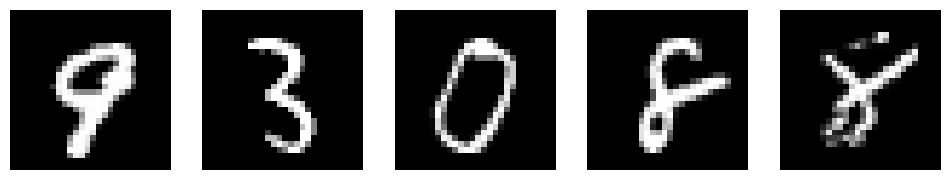

In [5]:
# Menampilkan 5 sampel gambar secara acak
plt.figure(figsize=(12,4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(random.choice(digits).reshape(28,28), cmap='gray')
    plt.axis("off")
plt.show()

Sekarang mari kita bagi 42.000 gambar tersebut menjadi set data pelatihan (*train*) dan data pengujian (*test*).


In [6]:
split = 0.7, 0.3 # 70% pelatihan, 30% pengujian

# Normalisasi data agar nilai piksel berada dalam rentang [0, 1]
digits /= 255.0

split_ind = int(len(digits)*split[0])
X_train, X_test, y_train, y_test = digits[:split_ind], digits[split_ind:], labels[:split_ind], labels[split_ind:]
print(f"Ukuran X_train: {X_train.shape}, Ukuran X_test: {X_test.shape}")

Ukuran X_train: (29399, 784), Ukuran X_test: (12601, 784)


Dengan `MLPClassifier` dari scikit-learn, kita dapat menggunakan metode validasi silang (*cross-validation*) untuk mengoptimalkan parameter berikut:

- **hidden_layer_sizes**: Menentukan jumlah neuron di setiap lapisan tersembunyi. Misalnya, `(100,)` berarti satu lapisan tersembunyi dengan 100 neuron.

- **alpha**: Kekuatan istilah regularisasi L2. Regularisasi membantu mencegah *overfitting* dengan membatasi besarnya bobot.

- **max_iter**: Jumlah maksimum iterasi. Solver akan melakukan iterasi sampai konvergen atau mencapai jumlah ini.

- **learning_rate_init**: Laju pembelajaran awal. Parameter ini mengontrol seberapa besar langkah yang diambil dalam memperbarui bobot.


Sebelum kita mencari set parameter yang optimal, mari kita mulai dengan `MLPClassifier` standar (tanpa tuning):


In [7]:
model = MLPClassifier().fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Akurasi MLPClassifier dengan parameter default: {accuracy_score(y_test, y_pred):.4f}")

Akurasi MLPClassifier dengan parameter default: 0.9707


In [8]:
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred))

Untuk pelatihan validasi silang, kita akan menggunakan aktivasi default "relu" dan solver default "adam".

Kita menggunakan **RandomizedSearchCV** alih-alih **GridSearchCV** untuk mengurangi waktu pelatihan. Berbeda dengan `GridSearchCV` yang mencoba semua kombinasi parameter, `RandomizedSearchCV` hanya mengambil sampel sejumlah nilai parameter dari distribusi yang ditentukan. Gambar berikut mengilustrasikan perbedaannya:

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L1/data/randomsearch.png" width="65%"></center>

<p style="text-align:center">
<a href="https://dl.acm.org/doi/pdf/10.5555/2188385.2188395"> Sumber: Makalah Random Search for Hyper-Parameter Optimization</a>
</p>


Seperti yang Anda lihat, titik-titik dalam ruang `GridSearch` terdistribusi secara merata. Proyeksi ke subruang parameter penting atau tidak penting menghasilkan cakupan yang sama. Ini kurang efisien karena kita ingin parameter yang penting memiliki lebih banyak cakupan dalam percobaan.

Sebaliknya, distribusi titik yang tidak merata dalam ruang `RandomSearch` memungkinkan percobaan untuk mengeksplorasi lebih banyak nilai berbeda di ruang parameter yang penting.


Meskipun kita menggunakan metode pencarian yang lebih efisien, **Anda harus tetap memperkirakan waktu pelatihan yang jauh lebih lama daripada melatih satu model saja**, karena kita mencoba beberapa nilai untuk beberapa parameter jaringan saraf.


In [9]:
parameters = {
    'hidden_layer_sizes': [50, 100, 200],
    'alpha': [0.001, 0.01, 0.1], 
    'max_iter': [200, 500], 
    'learning_rate_init': [0.001, 0.01, 0.1]
}

model = MLPClassifier()
# Gunakan subset data (3000 sampel) untuk mempercepat waktu demo di lab ini
clf = RandomizedSearchCV(estimator=model, param_distributions=parameters, cv=3, n_iter=5)
clf.fit(X_train[:3000], y_train[:3000]) 

print("Parameter terbaik yang ditemukan:\n")
print(clf.best_params_)

# Simpan model terbaik
bestmodel = clf.best_estimator_

Parameter terbaik yang ditemukan:

{'max_iter': 500, 'learning_rate_init': 0.001, 'hidden_layer_sizes': 200, 'alpha': 0.1}


Sekarang kita dapat menggunakan **bestmodel** (yang menggunakan set parameter paling optimal hasil temuan `RandomizedSearchCV`) untuk membuat prediksi pada data uji **X_test** dan mengevaluasi performanya.


Skor akurasi dari model terbaik adalah: 0.9380



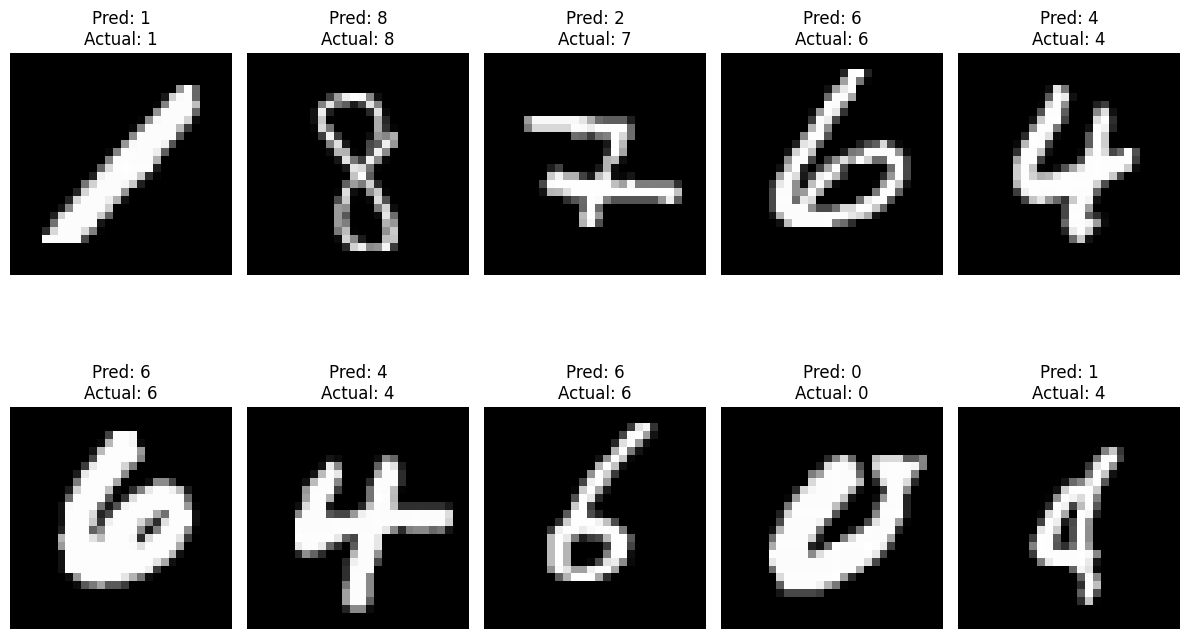

In [10]:
# Melakukan prediksi dengan model terbaik
y_pred_best = bestmodel.predict(X_test)
print(f"Skor akurasi dari model terbaik adalah: {accuracy_score(y_test, y_pred_best):.4f}\n")

# Visualisasi hasil prediksi pada 10 sampel acak
plt.figure(figsize=(12,8))
for i in range(10):
    plt.subplot(2, 5, i+1)
    # Pilih satu sampel secara acak dari X_test
    idx = random.randint(0, len(X_test)-1)
    sample = X_test[idx]
    actual_label = y_test.iloc[idx]
    
    # Prediksi label
    pred = bestmodel.predict(sample.reshape(1,-1))[0]
    
    plt.imshow(sample.reshape(28,28), cmap='gray')
    plt.title(f"Pred: {pred}\nActual: {actual_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Kesimpulan

Dalam lab ini, kita telah belajar cara:
1. Mempersiapkan data gambar untuk Jaringan Saraf Tiruan.
2. Membangun model klasifikasi menggunakan `MLPClassifier` dari scikit-learn.
3. Melakukan penyetelan hyperparameter (*hyperparameter tuning*) secara efisien menggunakan `RandomizedSearchCV`.

Model yang dihasilkan mampu mengenali digit tulisan tangan dengan tingkat akurasi yang sangat baik.


## Penulis

[Roxanne Li](https://www.linkedin.com/in/roxanne-li/) adalah magang Data Science di IBM Skills Network.

Copyright © 2022 IBM Corporation. All rights reserved.